# Crop Clinic — Model Training

Training Crop Clinic plant disease detection models using
[New Plant Diseases Dataset](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset).

### Output structure

```
models/
├── species_config.json          # master lookup used by the web app
├── apple/
│   ├── model.keras
│   └── class_names.txt
├── cherry/
│   ├── model.keras
│   └── class_names.txt
├── ...
```

Species with only one class (i.e. Blueberry, Orange, Raspberry, Soybean, Squash) don't
need a classifier. The app will return their single label directly. They are listed in
`species_config.json` with `"single_class": true`.

## 1 — Setup

In [2]:
import os, json, pathlib, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

# Configuration
IMAGE_SIZE   = 256                      # single source of truth
BATCH_SIZE   = 32
EPOCHS       = 15
SEED         = 42

# Reproducibility
tf.keras.utils.set_random_seed(SEED)


TensorFlow version: 2.21.0
GPUs available: []


## 2 — Download the dataset (Kaggle)

In [3]:
data_root = pathlib.Path("data")
data_root.mkdir(exist_ok=True)

In [6]:
!kaggle datasets download -d {kaggle_slug} -p "{data_root}"

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
new-plant-diseases-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
import os

# Fix Windows 260-char path limit
data_path = os.path.abspath("data")

with zipfile.ZipFile("data/new-plant-diseases-dataset.zip", "r") as z:
    z.extractall(f"\\\\?\\{data_path}")

## 3 — Locate train / validation directories

In [5]:
train_dir = data_root / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)" / "train"
val_dir   = data_root / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)" / "valid"

print("Train dir exists:", train_dir.exists())
print("Valid dir exists:", val_dir.exists())


Train dir exists: True
Valid dir exists: False


## 4 — Discover species and their classes

Each subfolder in the dataset is named `Species___Condition`.  We split on `___`
to group classes by species.

In [12]:
all_class_dirs = sorted([
    d.name for d in train_dir.iterdir() if d.is_dir()
])
print(f"Total class folders: {len(all_class_dirs)}")

# Group classes by species
species_classes: dict[str, list[str]] = {}
for class_name in all_class_dirs:
    species = class_name.split("___")[0]
    species_classes.setdefault(species, []).append(class_name)

# Separate into trainable (2+ classes) vs single-class species
trainable_species = {sp: cls for sp, cls in species_classes.items() if len(cls) >= 2}
single_class_species = {sp: cls[0] for sp, cls in species_classes.items() if len(cls) == 1}

print(f"\nTrainable species ({len(trainable_species)}):")
for sp, cls in trainable_species.items():
    print(f"  {sp}: {len(cls)} classes")

print(f"\nSingle-class species ({len(single_class_species)}) — no model needed:")
for sp, cls in single_class_species.items():
    print(f"  {sp}: {cls}")


Total class folders: 38

Trainable species (9):
  Apple: 4 classes
  Cherry_(including_sour): 2 classes
  Corn_(maize): 4 classes
  Grape: 4 classes
  Peach: 2 classes
  Pepper,_bell: 2 classes
  Potato: 3 classes
  Strawberry: 2 classes
  Tomato: 10 classes

Single-class species (5) — no model needed:
  Blueberry: Blueberry___healthy
  Orange: Orange___Haunglongbing_(Citrus_greening)
  Raspberry: Raspberry___healthy
  Soybean: Soybean___healthy
  Squash: Squash___Powdery_mildew


## 5 — Model architecture

The model accepts **raw uint8 images** and does all preprocessing (rescaling,
augmentation) internally. This eliminates the double-normalisation bug — the
serving code simply resizes the image and passes the uint8 array straight in.

Architecture:
- Data augmentation (flip, rotation, zoom) — only active during training
- Rescaling 0-255 → 0-1
- 4-block CNN (32 → 64 → 128 → 256 filters)
- GlobalAveragePooling → Dropout → Dense softmax

In [ ]:
def build_model(num_classes: int) -> keras.Model:
    """Build a CNN that accepts uint8 inputs and handles rescaling internally."""

    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), dtype="uint8", name="image")

    # Preprocessing
    x = layers.Rescaling(1.0 / 255, dtype="float32")(inputs)

    # Augmentation
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomZoom(0.15)(x)

    # Feature extraction 
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    # Classification head 
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="predictions")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Quick sanity check
_test_model = build_model(4)
_test_model.summary()
del _test_model


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,364 (1.49 MB)

 Trainable params: 390,404 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

## 6 — Data-loading helpers

`load_species_data` creates train and validation `tf.data.Dataset`s containing
**only** the classes for a given species. It uses the `class_names` parameter
of `image_dataset_from_directory` to filter, and the label indices will be
0 … N-1 relative to that species (exactly matching the saved `class_names.txt`).

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_species_data(species_name: str, class_list: list[str]):
    train_ds = keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
        class_names=class_list,        # filters to only these folders
    )

    val_ds = keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False,
        class_names=class_list,
    )

    class_names = train_ds.class_names 

    train_ds = train_ds.shuffle(1024).prefetch(AUTOTUNE)
    val_ds   = val_ds.prefetch(AUTOTUNE)
    return train_ds, val_ds, class_names


## 7 — Class-weight helper

In [ ]:
def compute_class_weights(class_list: list[str]) -> dict[int, float]:
    counts = []
    for cls in class_list:
        class_path = train_dir / cls
        n = len([f for f in class_path.iterdir() if f.is_file()])
        counts.append(n)

    total = sum(counts)
    n_classes = len(counts)
    weights = {}
    for i, c in enumerate(counts):
        weights[i] = total / (n_classes * c) if c > 0 else 0.0
    return weights


## 8 — Train one model per species


  TRAINING: Apple  (4 classes)
Found 7771 files belonging to 4 classes.
Found 1943 files belonging to 4 classes.
  Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']
Epoch 1/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.8864 - loss: 0.3134 - val_accuracy: 0.2265 - val_loss: 7.3011
Epoch 2/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9452 - loss: 0.1588 - val_accuracy: 0.6438 - val_loss: 1.3719
Epoch 3/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9593 - loss: 0.1225 - val_accuracy: 0.8574 - val_loss: 0.3530
Epoch 4/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9707 - loss: 0.0847 - val_accuracy: 0.7298 - val_loss: 1.0030
Epoch 5/15
  3/243 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.9878 - loss: 0.0766

W0000 00:00:1772195771.611419   27938 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166208 bytes after encountering the first element of size 25166208 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9722 - loss: 0.0811 - val_accuracy: 0.9439 - val_loss: 0.2128
Epoch 6/15
  4/243 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9707 - loss: 0.0859

W0000 00:00:1772195784.775969   27938 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166208 bytes after encountering the first element of size 25166208 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


243/243 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.9830 - loss: 0.0551 - val_accuracy: 0.7725 - val_loss: 0.9576
Epoch 7/15
  3/243 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.9878 - loss: 0.0286

W0000 00:00:1772195798.320768   28431 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1772195798.320885   27938 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166208 bytes after encountering the first element of size 25166208 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.9824 - loss: 0.0489 - val_accuracy: 0.9254 - val_loss: 0.2451
Epoch 8/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9869 - loss: 0.0365 - val_accuracy: 0.9501 - val_loss: 0.1272
Epoch 9/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9869 - loss: 0.0348 - val_accuracy: 0.8621 - val_loss: 0.6113
Epoch 10/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9906 - loss: 0.0293 - val_accuracy: 0.8909 - val_loss: 0.3647
Epoch 11/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9879 - loss: 0.0381 - val_accuracy: 0.9063 - val_loss: 0.3935
Epoch 12/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9929 - loss: 0.0206 - val_accuracy: 0.8765 - val_loss: 0.5019
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 8.
  ✓ Saved to models/apple/


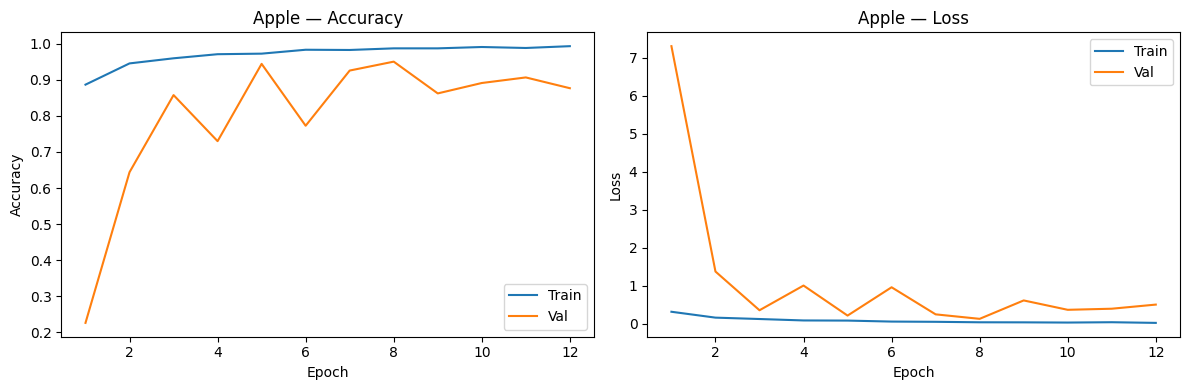

                          precision    recall  f1-score   support

      Apple___Apple_scab       0.97      0.90      0.93       504
       Apple___Black_rot       0.93      0.99      0.96       497
Apple___Cedar_apple_rust       1.00      0.91      0.95       440
         Apple___healthy       0.92      0.99      0.95       502

                accuracy                           0.95      1943
               macro avg       0.95      0.95      0.95      1943
            weighted avg       0.95      0.95      0.95      1943


  TRAINING: Cherry_(including_sour)  (2 classes)
Found 3509 files belonging to 2 classes.
Found 877 files belonging to 2 classes.
  Classes: ['Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy']
Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9729 - loss: 0.0896 - val_accuracy: 0.4800 - val_loss: 6.2751
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9915 - loss: 0.0332 - val_accuracy: 0.4800 - val_

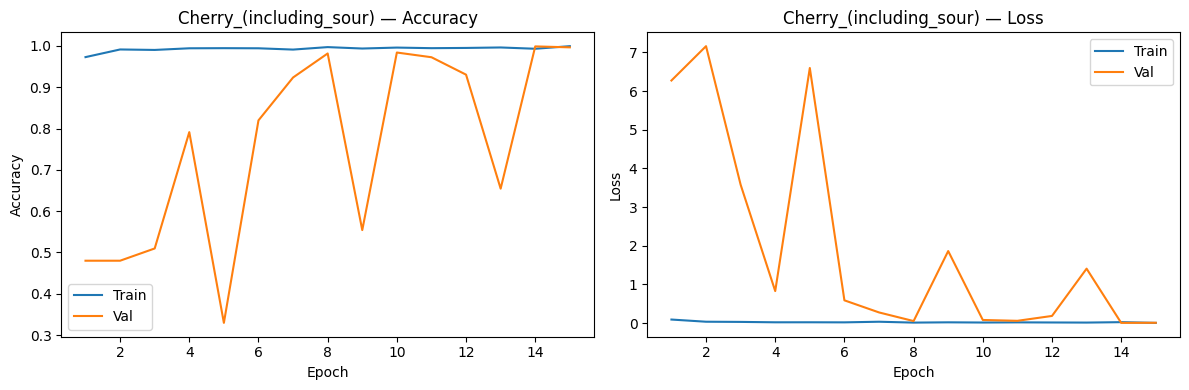

                                          precision    recall  f1-score   support

Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
       Cherry_(including_sour)___healthy       1.00      1.00      1.00       456

                                accuracy                           1.00       877
                               macro avg       1.00      1.00      1.00       877
                            weighted avg       1.00      1.00      1.00       877


  TRAINING: Corn_(maize)  (4 classes)
Found 7316 files belonging to 4 classes.
Found 1829 files belonging to 4 classes.
  Classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy']
Epoch 1/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.8809 - loss: 0.3142 - val_accuracy: 0.4040 - val_loss: 2.1661
Epoch 2/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.9307 - loss: 0.1956 - va

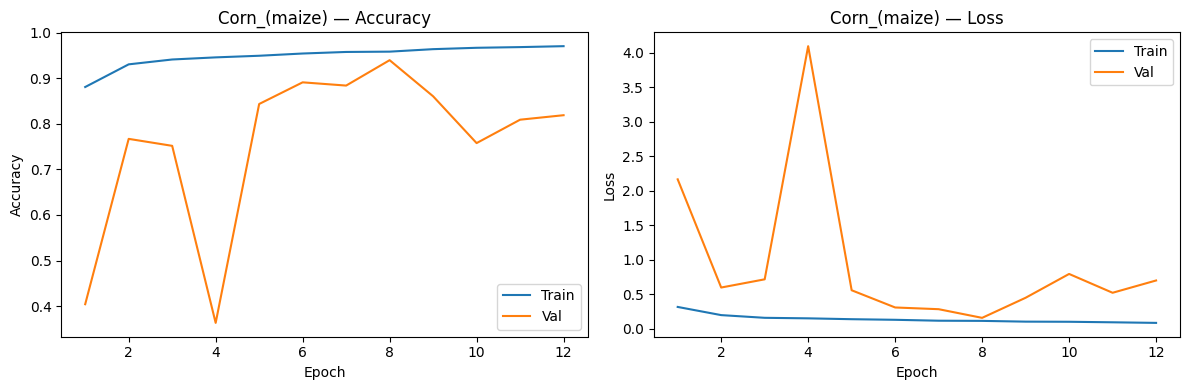

                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.82      0.86       410
                       Corn_(maize)___Common_rust_       0.97      1.00      0.98       477
               Corn_(maize)___Northern_Leaf_Blight       0.88      0.93      0.90       477
                            Corn_(maize)___healthy       1.00      1.00      1.00       465

                                          accuracy                           0.94      1829
                                         macro avg       0.94      0.94      0.94      1829
                                      weighted avg       0.94      0.94      0.94      1829


  TRAINING: Grape  (4 classes)
Found 7222 files belonging to 4 classes.
Found 1805 files belonging to 4 classes.
  Classes: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']
Epoch 1/15
226/22

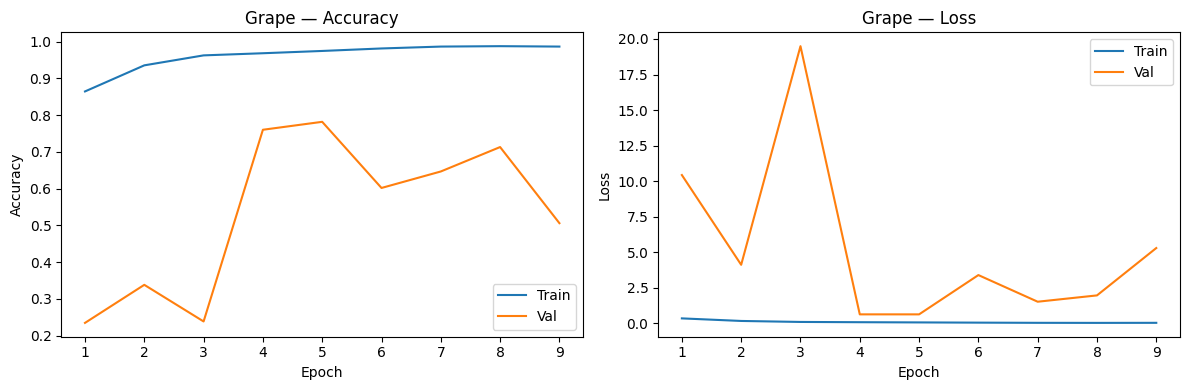

                                            precision    recall  f1-score   support

                         Grape___Black_rot       0.63      0.73      0.68       472
              Grape___Esca_(Black_Measles)       0.75      0.97      0.85       480
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       0.92      0.92      0.92       430
                           Grape___healthy       1.00      0.48      0.65       423

                                  accuracy                           0.78      1805
                                 macro avg       0.82      0.78      0.77      1805
                              weighted avg       0.82      0.78      0.77      1805


  TRAINING: Peach  (2 classes)
Found 3566 files belonging to 2 classes.
Found 891 files belonging to 2 classes.
  Classes: ['Peach___Bacterial_spot', 'Peach___healthy']
Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9582 - loss: 0.1168 - val_accuracy: 0.8171 - val_loss: 0.5670
Epoch 2/15
112/112 ━━━━━━━

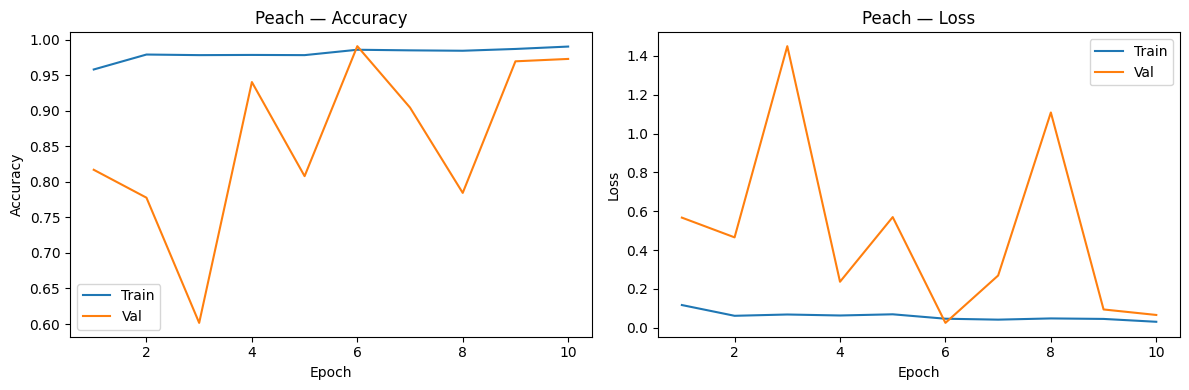

                        precision    recall  f1-score   support

Peach___Bacterial_spot       1.00      0.99      0.99       459
       Peach___healthy       0.99      1.00      0.99       432

              accuracy                           0.99       891
             macro avg       0.99      0.99      0.99       891
          weighted avg       0.99      0.99      0.99       891


  TRAINING: Pepper,_bell  (2 classes)
Found 3901 files belonging to 2 classes.
Found 975 files belonging to 2 classes.
  Classes: ['Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy']
Epoch 1/15
122/122 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.8880 - loss: 0.2740 - val_accuracy: 0.5097 - val_loss: 2.3310
Epoch 2/15
122/122 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9623 - loss: 0.1086 - val_accuracy: 0.6349 - val_loss: 0.7899
Epoch 3/15
122/122 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9749 - loss: 0.0798 - val_accuracy: 0.8256 - val_loss: 0.3692
Epoch 4/15
122/122 ━━━━━━━━━━━━━━━━

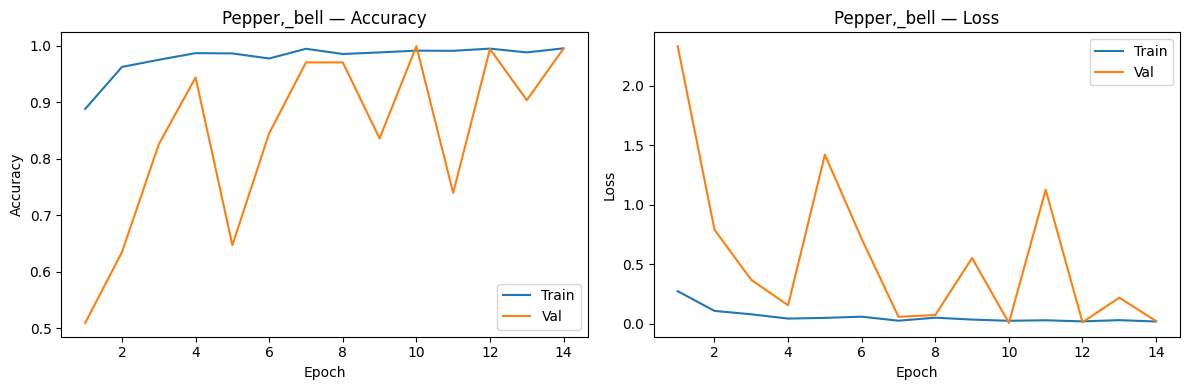

                               precision    recall  f1-score   support

Pepper,_bell___Bacterial_spot       1.00      1.00      1.00       478
       Pepper,_bell___healthy       1.00      1.00      1.00       497

                     accuracy                           1.00       975
                    macro avg       1.00      1.00      1.00       975
                 weighted avg       1.00      1.00      1.00       975


  TRAINING: Potato  (3 classes)
Found 5702 files belonging to 3 classes.
Found 1426 files belonging to 3 classes.
  Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Epoch 1/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.9342 - loss: 0.1921 - val_accuracy: 0.3401 - val_loss: 6.7405
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9593 - loss: 0.1081 - val_accuracy: 0.6220 - val_loss: 1.9360
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9667 - loss: 0.0930 - val_accuracy: 0.9039 - va

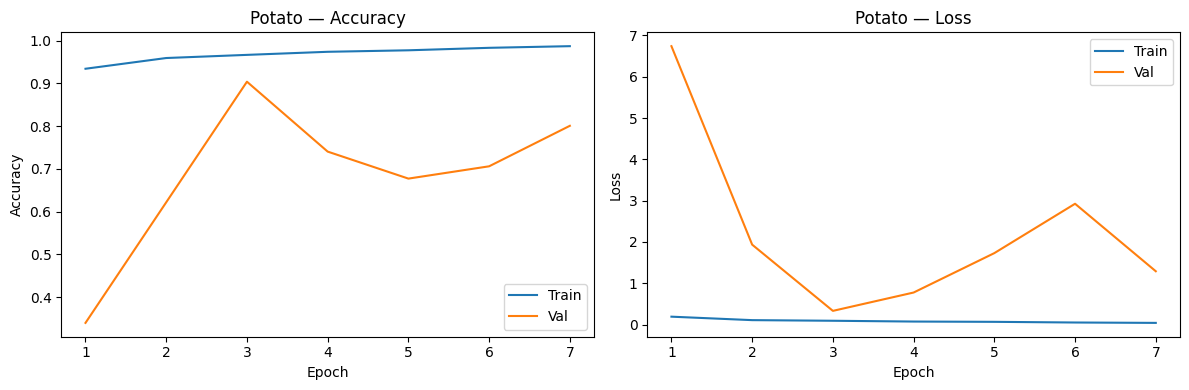

                       precision    recall  f1-score   support

Potato___Early_blight       0.84      1.00      0.91       485
 Potato___Late_blight       0.94      0.81      0.87       485
     Potato___healthy       0.95      0.90      0.93       456

             accuracy                           0.90      1426
            macro avg       0.91      0.90      0.90      1426
         weighted avg       0.91      0.90      0.90      1426


  TRAINING: Strawberry  (2 classes)
Found 3598 files belonging to 2 classes.
Found 900 files belonging to 2 classes.
  Classes: ['Strawberry___Leaf_scorch', 'Strawberry___healthy']
Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9514 - loss: 0.1367 - val_accuracy: 0.5856 - val_loss: 0.6157
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9883 - loss: 0.0308 - val_accuracy: 0.5589 - val_loss: 0.6290
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9928 - loss: 0.0218 - val_accuracy: 0.6678 - val_

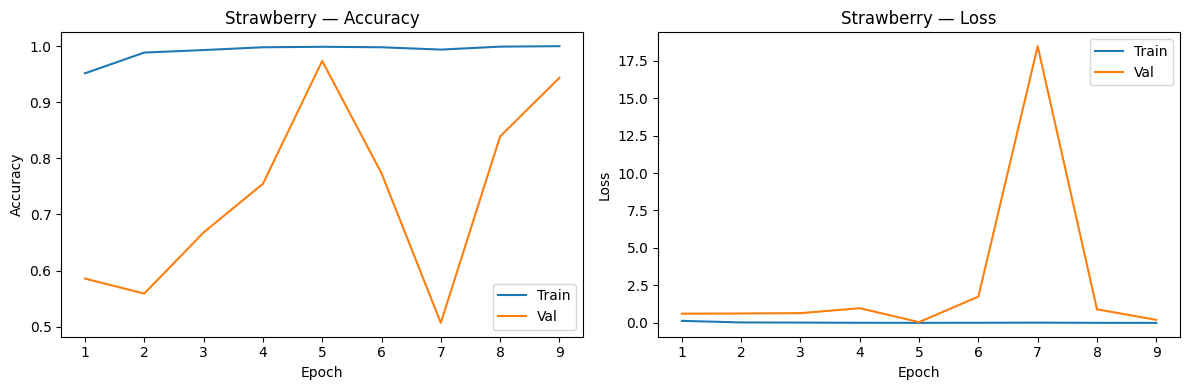

                          precision    recall  f1-score   support

Strawberry___Leaf_scorch       1.00      0.95      0.97       444
    Strawberry___healthy       0.95      1.00      0.97       456

                accuracy                           0.97       900
               macro avg       0.97      0.97      0.97       900
            weighted avg       0.97      0.97      0.97       900


  TRAINING: Tomato  (10 classes)
Found 18345 files belonging to 10 classes.
Found 4585 files belonging to 10 classes.
  Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Epoch 1/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.7363 - loss: 0.7807 - val_accuracy: 0.4744 - val_loss: 2.6312
Epoch 2/15
  3/574 ━━━━━━━━━━━━━━━━━━━━ 30s 

W0000 00:00:1772196591.871896   47685 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166208 bytes after encountering the first element of size 25166208 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


574/574 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.8564 - loss: 0.4296 - val_accuracy: 0.3795 - val_loss: 4.0892
Epoch 3/15
  3/574 ━━━━━━━━━━━━━━━━━━━━ 30s 53ms/step - accuracy: 0.8403 - loss: 0.4837

W0000 00:00:1772196624.957624   47685 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166208 bytes after encountering the first element of size 25166208 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


574/574 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.9016 - loss: 0.2944 - val_accuracy: 0.4833 - val_loss: 3.0871
Epoch 4/15
  3/574 ━━━━━━━━━━━━━━━━━━━━ 30s 53ms/step - accuracy: 0.9635 - loss: 0.1898

...

574/574 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.9561 - loss: 0.1285 - val_accuracy: 0.4916 - val_loss: 3.5594
Epoch 10/15
  3/574 ━━━━━━━━━━━━━━━━━━━━ 30s 53ms/step - accuracy: 0.9219 - loss: 0.1696

W0000 00:00:1772196857.262100   47685 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166208 bytes after encountering the first element of size 25166208 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


574/574 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.9615 - loss: 0.1143 - val_accuracy: 0.6685 - val_loss: 1.9608
Epoch 11/15
  3/574 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.9583 - loss: 0.0902

W0000 00:00:1772196890.228992   48605 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 41943296 bytes after encountering the first element of size 41943296 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1772196890.229087   47685 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 41943424 bytes after encountering the first element of size 41943424 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


574/574 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.9618 - loss: 0.1140 - val_accuracy: 0.5261 - val_loss: 3.3520
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 7.
  ✓ Saved to models/tomato/


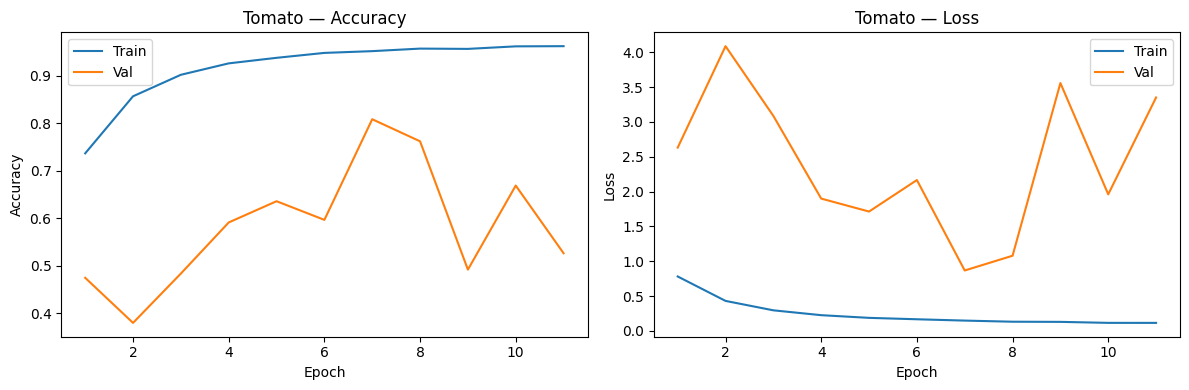

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.89      0.98      0.93       425
                        Tomato___Early_blight       0.98      0.68      0.80       480
                         Tomato___Late_blight       0.73      0.92      0.81       463
                           Tomato___Leaf_Mold       0.91      0.94      0.93       470
                  Tomato___Septoria_leaf_spot       0.93      0.87      0.90       436
Tomato___Spider_mites Two-spotted_spider_mite       0.70      0.64      0.67       435
                         Tomato___Target_Spot       0.97      0.33      0.49       457
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.91      0.95      0.93       490
                 Tomato___Tomato_mosaic_virus       0.98      0.77      0.86       448
                             Tomato___healthy       0.54      1.00      0.70       481

                                     accu

In [ ]:
from sklearn.metrics import classification_report

models_dir.mkdir(exist_ok=True)

species_config = {}

# Training each species 
for species_name, class_list in trainable_species.items():

    safe_name = species_name.lower().replace(" ", "_").replace(",", "").replace("(", "").replace(")", "")
    sp_dir = models_dir / safe_name
    if (sp_dir / "model.keras").exists():
        print(f"⏭ Skipping {species_name} — model already exists")
        continue
    sp_dir.mkdir(exist_ok=True)

    print("\n" + "=" * 70)
    print(f"  TRAINING: {species_name}  ({len(class_list)} classes)")
    print("=" * 70)

    # 1. Load data
    train_ds, val_ds, class_names = load_species_data(species_name, class_list)
    print(f"  Classes: {class_names}")

    # 2. Class weights
    class_weight = compute_class_weights(class_list)

    # 3. Build model
    model = build_model(num_classes=len(class_names))

    # 4. Train with early stopping
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=1,
    )

    # 5. Save model + class names
    model_path = sp_dir / "model.keras"
    model.save(model_path)

    with open(sp_dir / "class_names.txt", "w") as f:
        f.write("\n".join(class_names))

    print(f"  ✓ Saved to {sp_dir}/")

    # 6. Plot training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(1, len(history.history["accuracy"]) + 1)

    ax1.plot(epochs_range, history.history["accuracy"], label="Train")
    ax1.plot(epochs_range, history.history["val_accuracy"], label="Val")
    ax1.set_title(f"{species_name} — Accuracy")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy"); ax1.legend()

    ax2.plot(epochs_range, history.history["loss"], label="Train")
    ax2.plot(epochs_range, history.history["val_loss"], label="Val")
    ax2.set_title(f"{species_name} — Loss")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.legend()

    plt.tight_layout()
    plt.savefig(sp_dir / "training_curves.png", dpi=100)
    plt.show()

    # 7. Classification report
    y_true, y_pred = [], []
    for images, labels in val_ds:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    print(classification_report(y_true, y_pred, target_names=class_names))

    # 8. Register in config
    species_config[species_name] = {
        "safe_name": safe_name,
        "model_path": f"models/{safe_name}/model.keras",
        "class_names_path": f"models/{safe_name}/class_names.txt",
        "class_names": class_names,
        "num_classes": len(class_names),
        "single_class": False,
    }

    del model, train_ds, val_ds
    keras.backend.clear_session()
    import glob
    for f in glob.glob(f"/tmp/cache_{species_name}*"):
        os.remove(f)

print("\nAll trainable species done!")


## 9 — Register single-class species

In [17]:
for species_name, single_class in single_class_species.items():
    safe_name = species_name.lower().replace(" ", "_").replace(",", "").replace("(", "").replace(")", "")
    species_config[species_name] = {
        "safe_name": safe_name,
        "model_path": None,
        "class_names_path": None,
        "class_names": [single_class],
        "num_classes": 1,
        "single_class": True,
    }
    print(f"  {species_name}: → always returns '{single_class}'")


  Blueberry: → always returns 'Blueberry___healthy'
  Orange: → always returns 'Orange___Haunglongbing_(Citrus_greening)'
  Raspberry: → always returns 'Raspberry___healthy'
  Soybean: → always returns 'Soybean___healthy'
  Squash: → always returns 'Squash___Powdery_mildew'


## 10 — Save `species_config.json`

In [18]:
config_path = models_dir / "species_config.json"
with open(config_path, "w") as f:
    json.dump(species_config, f, indent=2)

print(f"Saved config to {config_path}")
print(f"\nSpecies available ({len(species_config)}):")
for sp, cfg in species_config.items():
    tag = "single-class" if cfg["single_class"] else f"{cfg['num_classes']} classes"
    print(f"  {sp}: {tag}")


Saved config to models/species_config.json

Species available (14):
  Apple: 4 classes
  Cherry_(including_sour): 2 classes
  Corn_(maize): 4 classes
  Grape: 4 classes
  Peach: 2 classes
  Pepper,_bell: 2 classes
  Potato: 3 classes
  Strawberry: 2 classes
  Tomato: 10 classes
  Blueberry: single-class
  Orange: single-class
  Raspberry: single-class
  Soybean: single-class
  Squash: single-class
